# FlyRank Capstone — Refresh / Content Opportunity Scoring
### Single-file Colab version — everything in one notebook, nothing to import

**Before running:** click the key icon (🔑) in the left sidebar → Secrets → add a new
secret named `HF_TOKEN` with your Hugging Face read token as the value, and toggle
"Notebook access" on for it. That's it — no .env file, no local paths.

In [ ]:
!pip install -q duckdb pyarrow scikit-learn pandas matplotlib

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")
con.sql(f"CREATE SECRET hf_token (TYPE huggingface, TOKEN '{HF_TOKEN}');")
print("DuckDB ready, token loaded.")

DuckDB ready, token loaded.


## 1. Load real data
Start with `USE_SAMPLE = True` (fast, small file) to confirm everything works,
then flip to `False` once you're ready to run on the full 78.8M-row table.

In [ ]:
USE_SAMPLE = True  # flip to False once this runs cleanly

fact_path = (
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance_sample.parquet"
    if USE_SAMPLE else
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/*.parquet"
)

df = con.sql(f"""
    WITH perf AS (
        SELECT
            client_hash_id,
            content_hash_id,
            report_date,
            gsc_clicks AS clicks,
            gsc_impressions AS impressions,
            gsc_avg_position AS position
        FROM '{fact_path}'
        WHERE gsc_data_available = true
    ),
    content AS (
        SELECT client_hash_id, content_hash_id, word_count, keyword_created_date
        FROM 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    ),
    joined AS (
        SELECT
            perf.client_hash_id || '_' || perf.content_hash_id AS page_id,
            perf.report_date,
            perf.clicks,
            perf.impressions,
            perf.position,
            content.word_count,
            content.keyword_created_date
        FROM perf
        JOIN content
          ON perf.client_hash_id = content.client_hash_id
         AND perf.content_hash_id = content.content_hash_id
    ),
    weekly AS (
        SELECT
            page_id,
            DATE_TRUNC('week', report_date) AS week_start,
            SUM(clicks) AS clicks,
            SUM(impressions) AS impressions,
            AVG(position) AS position,
            MAX(word_count) AS word_count,
            MAX(keyword_created_date) AS keyword_created_date
        FROM joined
        GROUP BY page_id, week_start
    )
    SELECT
        page_id,
        DENSE_RANK() OVER (ORDER BY week_start) - 1 AS week,
        clicks,
        impressions,
        CASE WHEN impressions > 0 THEN clicks::DOUBLE / impressions ELSE 0 END AS ctr,
        position,
        word_count,
        DATE_DIFF('day', keyword_created_date, week_start) AS days_since_publish
    FROM weekly
    ORDER BY page_id, week
""").df()

df["category"] = "unknown"  # no category dimension exists in this warehouse
print(df.shape)
df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(808519, 9)


,page_id,week,clicks,impressions,ctr,position,word_count,days_since_publish,category
0,client_06d356715a8ff3b6_content_0058bd88fb1821f2,1,0.0,30.0,0.000000,7.866516,2290,4,unknown
1,client_06d356715a8ff3b6_content_0058bd88fb1821f2,2,0.0,130.0,0.000000,8.215816,2290,11,unknown
2,client_06d356715a8ff3b6_content_0058bd88fb1821f2,3,0.0,57.0,0.000000,9.848180,2290,18,unknown
3,client_06d356715a8ff3b6_content_0058bd88fb1821f2,4,1.0,24.0,0.041667,22.555556,2290,25,unknown
4,client_06d356715a8ff3b6_content_0059a4d4195810c9,0,1.0,366.0,0.002732,11.455179,2087,56,unknown
5,client_06d356715a8ff3b6_content_0059a4d4195810c9,1,1.0,313.0,0.003195,13.928084,2087,63,unknown
6,client_06d356715a8ff3b6_content_0059a4d4195810c9,2,0.0,74.0,0.000000,17.968903,2087,70,unknown
7,client_06d356715a8ff3b6_content_0059a4d4195810c9,3,0.0,17.0,0.000000,7.869048,2087,77,unknown
8,client_06d356715a8ff3b6_content_0059a4d4195810c9,4,0.0,75.0,0.000000,5.301370,2087,84,unknown
9,client_06d356715a8ff3b6_content_005b6b7f7b8dda7f,0,0.0,243.0,0.000000,6.624704,2567,56,unknown


In [ ]:
# Sanity check
print("Unique pages:", df['page_id'].nunique())
print("Weeks available:", df['week'].min(), "to", df['week'].max())
df[['clicks','impressions','ctr','position']].describe()

Unique pages: 208636
Weeks available: 0 to 4


,clicks,impressions,ctr,position
count,808519.000000,808519.000000,808519.000000,808511.000000
mean,1.495471,267.396155,0.004987,22.158965
std,112.927772,1342.208061,0.030816,23.458597
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,6.000000,0.000000,6.450000
50%,0.000000,32.000000,0.000000,11.287982
75%,1.000000,142.000000,0.000768,30.666327
max,50920.000000,374119.000000,1.000000,633.000000


**Check the week range above.** The pipeline below assumes at least 20 weeks
of data (0-19), split as: features = weeks 0-11, label window = weeks 12-15,
test window = weeks 16-19. If your real max week is smaller, edit `FEATURE_WEEKS`,
`LABEL_WEEKS`, and `TEST_LABEL_WEEKS` in the next cell proportionally before continuing.

In [ ]:
FEATURE_WEEKS = range(0, 1)
LABEL_WEEKS = range(1, 3)
TEST_LABEL_WEEKS = range(3, 5)

def assert_no_window_overlap():
    f, l, t = set(FEATURE_WEEKS), set(LABEL_WEEKS), set(TEST_LABEL_WEEKS)
    assert f.isdisjoint(l) and f.isdisjoint(t) and l.isdisjoint(t), "Windows overlap!"
    print("Leakage check passed.")
    print(f"  feature weeks: {min(f)}-{max(f)}")
    print(f"  label weeks:   {min(l)}-{max(l)}")
    print(f"  test weeks:    {min(t)}-{max(t)}")

assert_no_window_overlap()

Leakage check passed.
  feature weeks: 0-0
  label weeks:   1-2
  test weeks:    3-4


## 2. Label, feature, and reason-code logic

In [ ]:
def compute_labels(df, label_weeks, growth_threshold=0.15):
    sub = df[df["week"].isin(label_weeks)].copy()
    print(f"Inside compute_labels: sub.shape = {sub.shape}") # DEBUG
    if sub.empty:
        print("Inside compute_labels: 'sub' is empty, returning empty DataFrame.") # DEBUG
        # Ensure consistent columns even if empty
        return pd.DataFrame(columns=["page_id", "label", "pct_change"])

    weeks_sorted = sorted(label_weeks)
    half = len(weeks_sorted) // 2
    early_half, late_half = weeks_sorted[:half], weeks_sorted[half:]

    all_page_ids = sub["page_id"].unique()
    print(f"Inside compute_labels: len(all_page_ids) = {len(all_page_ids)}") # DEBUG
    if len(all_page_ids) == 0:
        print("Inside compute_labels: 'all_page_ids' is empty, returning empty DataFrame.") # DEBUG
        return pd.DataFrame(columns=["page_id", "label", "pct_change"])

    early_clicks = sub[sub["week"].isin(early_half)].groupby("page_id")["clicks"].sum()
    early_clicks = early_clicks.reindex(all_page_ids, fill_value=0).rename("early_clicks")

    late_clicks = sub[sub["week"].isin(late_half)].groupby("page_id")["clicks"].sum()
    late_clicks = late_clicks.reindex(all_page_ids, fill_value=0).rename("late_clicks")

    result = pd.DataFrame({"early_clicks": early_clicks, "late_clicks": late_clicks})
    print(f"Inside compute_labels: result.shape before pct_change = {result.shape}") # DEBUG

    result["pct_change"] = np.where(
        result["early_clicks"] > 0,
        (result["late_clicks"] - result["early_clicks"]) / result["early_clicks"],
        np.where(result["late_clicks"] > 0, 1.0, 0.0),
    )

    def classify(pct):
        if pct >= growth_threshold: return "growing"
        elif pct <= -growth_threshold: return "declining"
        return "stable"

    result["label"] = result["pct_change"].apply(classify)
    print(f"Inside compute_labels: result.shape before return = {result.shape}") # DEBUG
    return result[["label", "pct_change"]].reset_index()


def build_features(df, feature_weeks):
    sub = df[df["week"].isin(feature_weeks)].copy()
    weeks_sorted = sorted(feature_weeks)

    agg = sub.groupby("page_id").agg(
        avg_clicks=("clicks", "mean"),
        avg_impressions=("impressions", "mean"),
        avg_ctr=("ctr", "mean"),
        avg_position=("position", "mean"),
        std_clicks=("clicks", "std"),
        word_count=("word_count", "first"),
        category=("category", "first"),
        days_since_publish=("days_since_publish", "max"),
    ).fillna(0)

    half = len(weeks_sorted) // 2
    early_w, late_w = weeks_sorted[:half], weeks_sorted[half:]
    early = sub[sub["week"].isin(early_w)].groupby("page_id")["clicks"].mean()
    late = sub[sub["week"].isin(late_w)].groupby("page_id")["clicks"].mean()
    agg["trend_slope"] = (late - early).reindex(agg.index).fillna(0)

    agg = pd.get_dummies(agg, columns=["category"], prefix="cat")
    return agg.reset_index()


def generate_reason_code(row):
    reasons = []
    if row.get("trend_slope", 0) < -5: reasons.append("clicks trending down within observation window")
    elif row.get("trend_slope", 0) > 5: reasons.append("clicks trending up within observation window")
    if row.get("avg_ctr", 0) < 0.02: reasons.append("CTR below typical range for its position")
    if row.get("avg_position", 0) > 20: reasons.append("ranking outside top 20 on average")
    if row.get("days_since_publish", 0) > 730: reasons.append("content is 2+ years old, candidate for refresh")
    if not reasons: reasons.append("no strong signal — monitor")
    return "; ".join(reasons)


def recommend_action(predicted_label, row):
    if predicted_label == "declining":
        return "improve" if row.get("avg_position", 0) <= 10 else "rewrite"
    elif predicted_label in ("recovering", "growing"):
        return "protect"
    else:
        return "improve" if row.get("word_count", 0) < 500 else "monitor"

print("Functions defined.")

Functions defined.


## 3. Labels, features, and split

In [ ]:
labels = compute_labels(df, LABEL_WEEKS)
print(labels['label'].value_counts(normalize=True).round(3))

features = build_features(df, FEATURE_WEEKS)
data = features.merge(labels, on="page_id", how="inner")
print(data.shape)
data.head()

Inside compute_labels: sub.shape = (329803, 9)
Inside compute_labels: len(all_page_ids) = 178068
Inside compute_labels: result.shape before pct_change = (178068, 2)
Inside compute_labels: result.shape before return = (178068, 4)
label
stable       0.715
declining    0.157
growing      0.128
Name: proportion, dtype: float64
(156581, 12)


,page_id,avg_clicks,avg_impressions,avg_ctr,avg_position,std_clicks,word_count,days_since_publish,trend_slope,cat_unknown,label,pct_change
0,client_06d356715a8ff3b6_content_0059a4d4195810c9,1.0,366.0,0.002732,11.455179,0.0,2087,56,0.0,True,declining,-1.0
1,client_06d356715a8ff3b6_content_005b6b7f7b8dda7f,0.0,243.0,0.000000,6.624704,0.0,2567,56,0.0,True,declining,-1.0
2,client_06d356715a8ff3b6_content_0094c7d0fbcc07b7,0.0,47.0,0.000000,35.507143,0.0,2449,25,0.0,True,stable,0.0
3,client_06d356715a8ff3b6_content_00a34394d4ee05ce,0.0,28.0,0.000000,12.738095,0.0,2362,25,0.0,True,growing,1.0
4,client_06d356715a8ff3b6_content_0153b7dedc3fc40d,0.0,312.0,0.000000,5.875168,0.0,2092,56,0.0,True,growing,1.0


In [ ]:
from sklearn.model_selection import train_test_split

unique_ids = list(data["page_id"].unique())
train_ids, val_ids = train_test_split(unique_ids, test_size=0.25, random_state=42)
train = data[data["page_id"].isin(train_ids)]
val = data[data["page_id"].isin(val_ids)]
print("train:", train.shape, "val:", val.shape)

train: (117435, 12) val: (39146, 12)


## 4. Baseline vs. model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

feature_cols = [c for c in train.columns if c not in
                ("page_id", "label", "pct_change", "early_clicks", "late_clicks")]
X_train, y_train = train[feature_cols], train["label"]
X_val, y_val = val[feature_cols], val["label"]

def baseline_predict(X):
    preds = []
    for slope in X["trend_slope"]:
        if slope > 2: preds.append("growing")
        elif slope < -2: preds.append("declining")
        else: preds.append("stable")
    return preds

baseline_preds = baseline_predict(X_val)
print("Baseline accuracy:", round(accuracy_score(y_val, baseline_preds), 3))
print(classification_report(y_val, baseline_preds, zero_division=0))

Baseline accuracy: 0.688
              precision    recall  f1-score   support

   declining       0.00      0.00      0.00      6862
     growing       0.00      0.00      0.00      5370
      stable       0.69      1.00      0.81     26914

    accuracy                           0.69     39146
   macro avg       0.23      0.33      0.27     39146
weighted avg       0.47      0.69      0.56     39146



In [ ]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
model_preds = model.predict(X_val)

print("Model accuracy:", round(accuracy_score(y_val, model_preds), 3))
print(classification_report(y_val, model_preds, zero_division=0))

Model accuracy: 0.724
              precision    recall  f1-score   support

   declining       0.44      0.47      0.46      6862
     growing       0.36      0.01      0.02      5370
      stable       0.79      0.93      0.86     26914

    accuracy                           0.72     39146
   macro avg       0.53      0.47      0.44     39146
weighted avg       0.67      0.72      0.67     39146



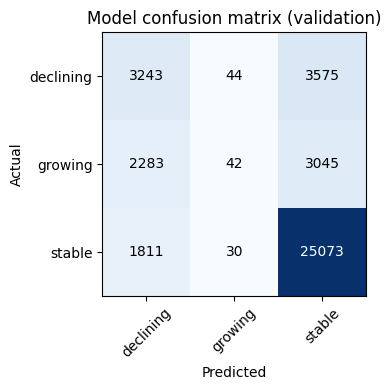

In [ ]:
labels_order = sorted(y_val.unique())
cm = confusion_matrix(y_val, model_preds, labels=labels_order)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45)
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Model confusion matrix (validation)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

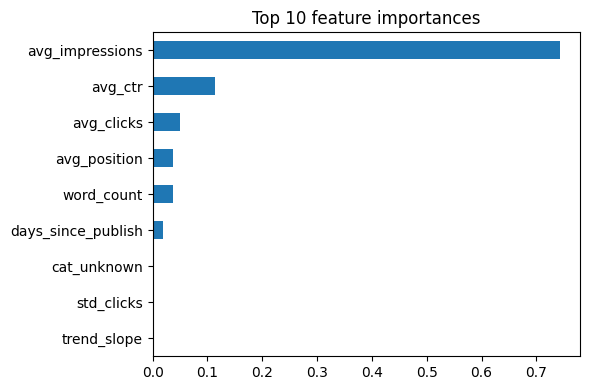

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6,4))
importances.tail(10).plot.barh(ax=ax)
ax.set_title("Top 10 feature importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 5. Final held-out test + ranked recommendations

In [ ]:
test_labels = compute_labels(df, TEST_LABEL_WEEKS)
test_features = build_features(df, FEATURE_WEEKS)  # still only weeks 0-11
test_data = test_features.merge(test_labels, on="page_id")

test_preds = model.predict(test_data[feature_cols])
print("FINAL held-out test accuracy:", round(accuracy_score(test_data["label"], test_preds), 3))
print(classification_report(test_data["label"], test_preds, zero_division=0))

Inside compute_labels: sub.shape = (308102, 9)
Inside compute_labels: len(all_page_ids) = 175767
Inside compute_labels: result.shape before pct_change = (175767, 2)
Inside compute_labels: result.shape before return = (175767, 4)
FINAL held-out test accuracy: 0.8
              precision    recall  f1-score   support

   declining       0.67      0.55      0.60     35391
     growing       0.08      0.01      0.01      5885
      stable       0.84      0.93      0.88    104758

    accuracy                           0.80    146034
   macro avg       0.53      0.50      0.50    146034
weighted avg       0.77      0.80      0.78    146034



In [ ]:
test_data["predicted_label"] = test_preds
test_data["reason_code"] = test_data.apply(generate_reason_code, axis=1)
test_data["action"] = test_data.apply(lambda r: recommend_action(r["predicted_label"], r), axis=1)

def priority_score(row):
    score = 0
    if row["predicted_label"] == "declining":
        score += 100 - min(row["avg_position"], 100)
        score += 20
    elif row["predicted_label"] == "recovering":
        score += 15
    elif row["predicted_label"] == "stable" and row["word_count"] < 500:
        score += 10
    return round(score, 1)

test_data["priority_score"] = test_data.apply(priority_score, axis=1)

recommendations = (test_data[test_data["priority_score"] > 0]
    [["page_id","predicted_label","avg_position","avg_ctr","word_count",
      "action","reason_code","priority_score"]]
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True))

print(f"{len(recommendations)} pages flagged out of {len(test_data)} total")
recommendations.to_csv("ranked_recommendations.csv", index=False)
recommendations.head(20)

62805 pages flagged out of 146034 total


,page_id,predicted_label,avg_position,avg_ctr,word_count,action,reason_code,priority_score
0,client_8ddc46da5414ffd8_content_d584c27d7f8ded3b,declining,0.469720,0.000773,3057,improve,CTR below typical range for its position,119.5
1,client_73cda7b4e4f265ea_content_de9e46db895234a3,declining,0.626859,0.041485,0,improve,no strong signal — monitor,119.4
2,client_62f4a7e64f5e0096_content_674f272dbd3142d9,declining,0.670553,0.000676,2954,improve,CTR below typical range for its position,119.3
3,client_62f4a7e64f5e0096_content_8022d335a0934e80,declining,0.814385,0.004193,0,improve,CTR below typical range for its position,119.2
4,client_23a62021009f63c4_content_829a0bbd0e03ebda,declining,0.915870,0.010345,6493,improve,CTR below typical range for its position,119.1
5,client_e547b89c05043229_content_f43b95944a9fa212,declining,0.941323,0.000273,0,improve,CTR below typical range for its position,119.1
6,client_a80fca3f171ed1de_content_7fc1e18f7e819b5e,declining,1.048497,0.005263,3100,improve,CTR below typical range for its position,119.0
7,client_62f4a7e64f5e0096_content_96e38372f2bf403e,declining,1.189482,0.014493,2112,improve,CTR below typical range for its position,118.8
8,client_62f4a7e64f5e0096_content_a907435581852c43,declining,1.347705,0.022374,0,improve,no strong signal — monitor,118.7
9,client_23a62021009f63c4_content_f81b8e9b0726d84f,declining,1.277778,0.000000,8880,improve,CTR below typical range for its position,118.7


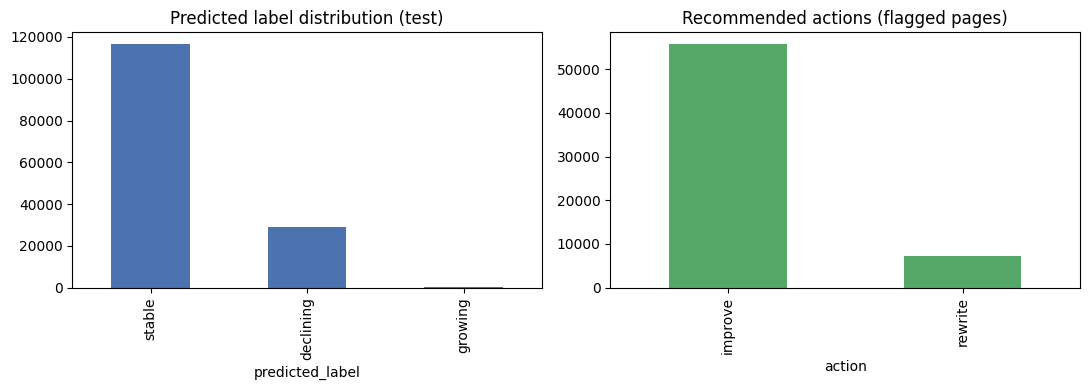

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
test_data["predicted_label"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Predicted label distribution (test)")
recommendations["action"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Recommended actions (flagged pages)")
plt.tight_layout()
plt.savefig("summary_charts.png", dpi=150)
plt.show()

## Done
Download `ranked_recommendations.csv`, `confusion_matrix.png`, `feature_importance.png`,
and `summary_charts.png` from the Colab file browser (folder icon, left sidebar) —
these go into your paper's Results and Ranked Recommendations sections.

**Reminder:** once `USE_SAMPLE = True` above works cleanly, change it to `False`
and re-run the whole notebook (Runtime → Run all) for real full-scale numbers.